# Sleep Debt Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/bedtime_screentime_sleep_debt.csv')

In [3]:
df.head()

,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
0,USR-00001,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt
1,USR-00002,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt
2,USR-00003,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt
3,USR-00004,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7,Mild Deficit
4,USR-00005,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3,Moderate Debt


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8500 non-null   str    
 1   age                       8500 non-null   int64  
 2   gender                    8500 non-null   str    
 3   occupation_type           8500 non-null   str    
 4   chronotype                8500 non-null   str    
 5   bedtime_phone_minutes     8500 non-null   int64  
 6   primary_bedtime_app       8500 non-null   str    
 7   screen_brightness_pct     8500 non-null   int64  
 8   blue_light_filter_active  8500 non-null   int64  
 9   caffeine_post_5pm_mg      8500 non-null   int64  
 10  physical_activity_min     8500 non-null   int64  
 11  sleep_latency_min         8500 non-null   float64
 12  total_sleep_hours         8500 non-null   float64
 13  deep_sleep_pct            8500 non-null   float64
 14  rem_sleep_pct      

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,8500.0,34.355647,11.584259,18.0,25.00,32.00,42.00,65.0
bedtime_phone_minutes,8500.0,59.250000,36.931991,1.0,31.00,51.00,79.00,180.0
screen_brightness_pct,8500.0,55.153882,19.850550,10.0,42.00,55.00,69.00,100.0
blue_light_filter_active,8500.0,0.467765,0.498989,0.0,0.00,0.00,1.00,1.0
caffeine_post_5pm_mg,8500.0,33.222471,51.935645,0.0,0.00,0.00,55.00,250.0
physical_activity_min,8500.0,35.701412,20.819390,0.0,21.00,35.00,50.00,112.0
sleep_latency_min,8500.0,40.671471,17.444914,6.0,28.20,37.60,49.70,123.3
total_sleep_hours,8500.0,6.266209,1.446258,3.2,5.24,6.33,7.35,9.8
deep_sleep_pct,8500.0,21.735741,3.069377,8.1,19.70,21.90,23.90,28.0
rem_sleep_pct,8500.0,19.105859,2.546459,9.6,17.40,19.10,20.80,27.0


In [6]:
df.describe(include='str').T

,count,unique,top,freq
user_id,8500,8500,USR-00001,1
gender,8500,3,Female,4347
occupation_type,8500,5,Corporate 9-to-5,2838
chronotype,8500,3,Intermediate,3880
primary_bedtime_app,8500,6,TikTok / Reels,2198
sleep_debt_category,8500,4,Moderate Debt,4462


In [7]:
df['gender'] = df['gender'].astype('category')

In [8]:
df['occupation_type'] = df['occupation_type'].astype('category')

In [9]:
df['chronotype'].unique()

<StringArray>
['Intermediate', 'Night Owl', 'Morning Lark']
Length: 3, dtype: str

In [10]:
df['chronotype'] = pd.Categorical(df['chronotype'], categories=['Morning Lark', 'Intermediate', 'Night Owl'], ordered=True)

In [11]:
df['primary_bedtime_app'] = df['primary_bedtime_app'].astype('category')

In [12]:
df['sleep_debt_category'].unique()

<StringArray>
['Severe Sleep Debt', 'Mild Deficit', 'Moderate Debt', 'Optimal Recovery']
Length: 4, dtype: str

In [13]:
df['sleep_debt_category'] = pd.Categorical(df['sleep_debt_category'], categories=['Optimal Recovery', 'Mild Deficit', 'Moderate Debt', 'Severe Sleep Debt'], ordered=True)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   user_id                   8500 non-null   str     
 1   age                       8500 non-null   int64   
 2   gender                    8500 non-null   category
 3   occupation_type           8500 non-null   category
 4   chronotype                8500 non-null   category
 5   bedtime_phone_minutes     8500 non-null   int64   
 6   primary_bedtime_app       8500 non-null   category
 7   screen_brightness_pct     8500 non-null   int64   
 8   blue_light_filter_active  8500 non-null   int64   
 9   caffeine_post_5pm_mg      8500 non-null   int64   
 10  physical_activity_min     8500 non-null   int64   
 11  sleep_latency_min         8500 non-null   float64 
 12  total_sleep_hours         8500 non-null   float64 
 13  deep_sleep_pct            8500 non-null   float64 
 14  rem

In [16]:
# pd.crosstab(df['occupation_type'], df['sleep_debt_category'], normalize='index') * 100

In [35]:
target = 'total_sleep_hours'

<Axes: xlabel='age', ylabel='total_sleep_hours'>

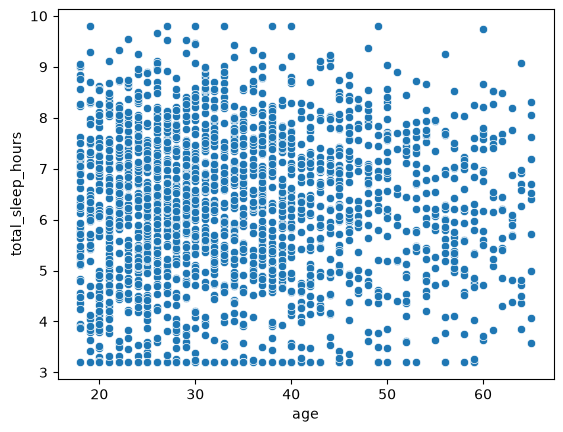

In [38]:
sns.scatterplot(data=df.sample(frac=0.25), x='age', y=df[target])

In [41]:
df['age'].describe()

count    8500.000000
mean       34.355647
std        11.584259
min        18.000000
25%        25.000000
50%        32.000000
75%        42.000000
max        65.000000
Name: age, dtype: float64

In [47]:
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df['age_bins'] = pd.cut(df['age'], bins=bins, labels=labels)

<Axes: xlabel='age_bins', ylabel='total_sleep_hours'>

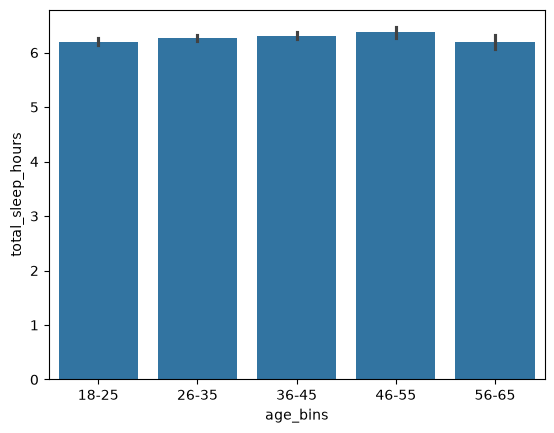

In [51]:
sns.barplot(data=df, x='age_bins', y=target)

<Axes: xlabel='total_sleep_hours', ylabel='Count'>

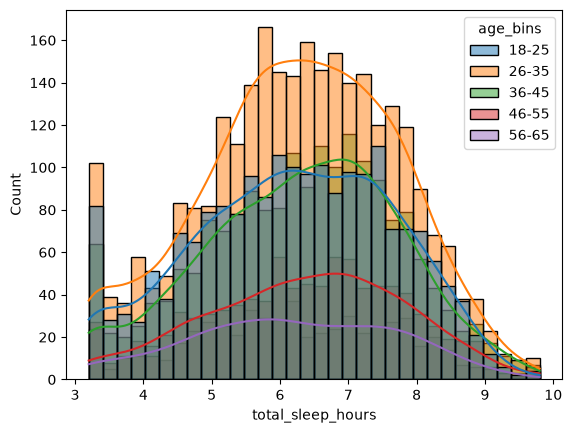

In [54]:
sns.histplot(data=df, x=target, hue='age_bins', kde=True)